# 08 - Gated Recurrent Unit (GRU)



---

In the previous notebook, we learned about Long Short-Term Memory (LSTM).

LSTM solved the vanishing gradient problem using memory cells and three gates.

However, LSTM has many parameters and is computationally expensive.

Researchers asked:

Can we build a simpler recurrent network that performs almost as well?

The answer was the **Gated Recurrent Unit (GRU)**.

## 📜 History

LSTM was a major improvement over RNN.

However, it contains:

- Forget Gate
- Input Gate
- Output Gate
- Cell State
- Hidden State

This makes it relatively complex.

In 2014, researchers **:contentReference[oaicite:0]{index=0}** and collaborators introduced the **Gated Recurrent Unit (GRU)**.

The goal was simple:

- Fewer gates
- Fewer parameters
- Faster training
- Similar performance

## ❌ Limitations of LSTM

Although LSTM solves long-term memory problems, it has some drawbacks.

- Three gates
- Cell state
- More parameters
- Higher computational cost
- Longer training time

Researchers wanted a lighter architecture without sacrificing much accuracy.

## 💡 Core Idea

GRU combines the ideas of remembering and forgetting into a simpler design.

Instead of three gates, it uses only two:

1. Update Gate
2. Reset Gate

It also removes the separate Cell State.

This makes GRU easier to train while still handling long-term dependencies.


## 🧠 Human Analogy

Imagine you're reading a book.

Sometimes you keep old information.

Sometimes you ignore it and focus on new information.

GRU learns these decisions automatically.

- **Update Gate** decides how much past information to keep.
- **Reset Gate** decides how much past information to ignore when processing new input.

In [1]:
memory = ["I", "love"]

print("Old Memory:", memory)

new_word = "AI"

# Imagine the Update Gate decides to keep previous memory
memory.append(new_word)

print("Updated Memory:", memory)

Old Memory: ['I', 'love']
Updated Memory: ['I', 'love', 'AI']


## 🧠 Update Gate

The Update Gate controls how much information from the previous hidden state should be carried forward.

If the value is close to **1**, the model keeps most of the previous information.

If the value is close to **0**, the model replaces it with new information.

## 🧠 Reset Gate

The Reset Gate decides how much previous information should be ignored when calculating the new hidden state.

This helps the model forget information that is no longer useful.

## 📊 GRU Architecture

```
Previous Hidden State
        │
        ▼
   Update Gate
        │
        ▼
    Reset Gate
        │
        ▼
 New Hidden State
```

Unlike LSTM, there is **no separate Cell State**.

## ➗ Mathematics

Update Gate

\[
z_t=\sigma(W_z[h_{t-1},x_t])
\]

Reset Gate

\[
r_t=\sigma(W_r[h_{t-1},x_t])
\]

Candidate Hidden State

\[
\tilde h_t=\tanh(W_h[r_t*h_{t-1},x_t])
\]

Final Hidden State

\[
h_t=(1-z_t)h_{t-1}+z_t\tilde h_t
\]

The key idea:

- Update Gate → Keep or replace information
- Reset Gate → Forget irrelevant information

### Sigmoid Visualization

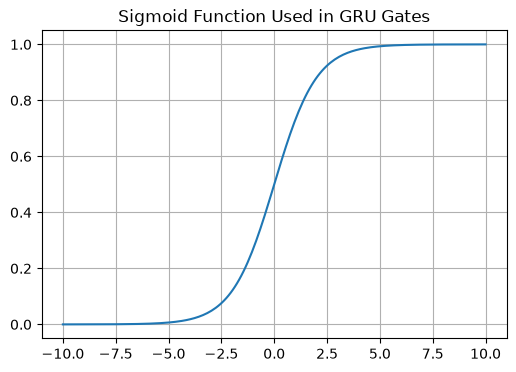

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.title("Sigmoid Function Used in GRU Gates")
plt.grid()
plt.show()

### Build a GRU


In [3]:
import torch
import torch.nn as nn

gru = nn.GRU(
    input_size=5,
    hidden_size=4,
    batch_first=True
)

print(gru)

GRU(5, 4, batch_first=True)


In [4]:
x = torch.randn(1, 6, 5)

output, hidden = gru(x)

print("Output Shape:", output.shape)
print("Hidden Shape:", hidden.shape)

Output Shape: torch.Size([1, 6, 4])
Hidden Shape: torch.Size([1, 1, 4])


GRU only returns:

Output
Hidden State

There is no Cell State.

## 📊 RNN vs LSTM vs GRU

| Feature | RNN | LSTM | GRU |
|---------|-----|------|-----|
| Memory | Hidden State | Hidden + Cell State | Hidden State |
| Gates | None | 3 | 2 |
| Long-term Memory | Poor | Excellent | Excellent |
| Training Speed | Fast | Slower | Faster than LSTM |
| Parameters | Few | Most | Fewer than LSTM |

## ✅ Advantages

- Simpler than LSTM
- Faster training
- Fewer parameters
- Handles long-term dependencies
- Performs well on many NLP tasks

## ❌ Disadvantages

GRU still processes sequences one word at a time.

This means:

- Training cannot be fully parallelized.
- Long sequences are still computationally expensive.

Researchers wanted a better approach.

Instead of processing one word after another, they asked:

**Can the model look at the entire sentence at once?**

Before reaching that idea, another important milestone was the **Encoder–Decoder (Seq2Seq)** architecture.

## 🌍 Applications

GRU has been used in:

- Machine Translation
- Speech Recognition
- Chatbots
- Text Generation
- Time-Series Forecasting
- Sentiment Analysis

## ✅ Summary

Today I learned:

- Why GRU was introduced.
- The purpose of the Update and Reset Gates.
- How GRU simplifies LSTM.
- How to build a GRU in PyTorch.
- Why GRU is often faster than LSTM.